In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import glob


def load_experiment_results(path):
    import re
    model_slug = re.match(r"^(.*/)?elicit-beliefs-(.*)\.pt$", path).group(2)
    data = torch.load(path, weights_only=False)
    logits = data["logits"]
    top_other_logit = data["top_other_logit"]
    top_other_id = data["top_other_id"]
    top_other_token = data["top_other_token"]
    return model_slug, logits, top_other_logit, top_other_id, top_other_token


def compute_metrics(p_affirm, logits, top_other_logit):
    mean_p_affirm = p_affirm.mean(dim=1)
    certainty = np.array(torch.vstack((mean_p_affirm, 1 - mean_p_affirm)).max(axis=0))

    stdev_p_affirm = p_affirm.std(dim=1)
    stability = np.array(1 - 2 * stdev_p_affirm)

    # TODO: Leakage is computed is the sum of all other tokens, excluding
    # Yes, No, True, False, which isn't quite right since we should use either
    # (Yes, No) or (True, False) as viable tokens and not all 4 of them. That
    # depends on which prompt template was used though so, for now, this
    # calculation is good enough.
    all_logits = torch.hstack((logits, top_other_logit[:, None]))
    all_probs = all_logits.softmax(axis=1)
    leakage = np.array(all_probs[:, 4:].sum(axis=1))

    aggregate_function = np.mean
    
    return {
        'certainty': aggregate_function(certainty),
        'stability': aggregate_function(stability),
        'leakage': aggregate_function(leakage),
    }

In [2]:
from mycode import WORDS, YES, NO, TRUE, FALSE, PROMPT_TEMPLATES, logits_to_affirm_prob, present_results

In [3]:
print("| Model | Certainty in [0.5, 1] | Stability in [0.5, 1] | Leakage in [0, 1] |")
print("|-------|:---------------------:|:---------------------:|:-----------------:|")
all_metrics = {}
for path in glob.glob("results/*.pt"):
    model_slug, logits, top_other_logit, top_other_id, top_other_token = load_experiment_results(path)
    p_affirm = logits_to_affirm_prob(logits)
    all_metrics[model_slug] = compute_metrics(p_affirm, logits, top_other_logit)

for model_slug, metrics in sorted(all_metrics.items(), key=lambda item: item[1]['stability'], reverse=True):
    if metrics['leakage'] < 0.9:
        print(f"| {model_slug} | {metrics['certainty']:.2f} | {metrics['stability']:.2f} | {metrics['leakage']:.3f} | ")

| Model | Certainty in [0.5, 1] | Stability in [0.5, 1] | Leakage in [0, 1] |
|-------|:---------------------:|:---------------------:|:-----------------:|


/var/folders/h2/n9tkny1d1wl46ndfc_hgtt_40000gn/T/ipykernel_28724/3796463502.py:23: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  stability = np.array(1 - 2 * stdev_p_affirm)
/var/folders/h2/n9tkny1d1wl46ndfc_hgtt_40000gn/T/ipykernel_28724/3796463502.py:32: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  leakage = np.array(all_probs[:, 4:].sum(axis=1))


| gemma-4-31B-it | 0.77 | 0.98 | 0.024 | 
| Qwen2.5-72B-Instruct | 0.81 | 0.98 | 0.046 | 
| gemma-4-E4B-it | 0.83 | 0.97 | 0.104 | 
| Qwen2.5-14B-Instruct | 0.83 | 0.97 | 0.066 | 
| Qwen2.5-7B-Instruct | 0.83 | 0.97 | 0.038 | 
| gemma-4-12B-it | 0.79 | 0.97 | 0.060 | 
| phi-4 | 0.79 | 0.96 | 0.030 | 
| Qwen2.5-32B-Instruct | 0.81 | 0.96 | 0.020 | 
| Phi-3.5-mini-instruct | 0.78 | 0.95 | 0.067 | 
| Meta-Llama-3-8B-Instruct | 0.81 | 0.95 | 0.116 | 
| Llama-3.1-70B-Instruct | 0.75 | 0.95 | 0.037 | 
| OLMo-2-1124-13B-Instruct | 0.80 | 0.95 | 0.007 | 
| Meta-Llama-3-70B-Instruct | 0.75 | 0.95 | 0.278 | 
| OLMo-2-0325-32B-Instruct | 0.75 | 0.93 | 0.021 | 
| Phi-3-mini-128k-instruct | 0.76 | 0.92 | 0.014 | 
| Llama-3.1-8B-Instruct | 0.73 | 0.92 | 0.066 | 
| Llama-4-Scout-17B-16E-Instruct | 0.79 | 0.91 | 0.307 | 
| Qwen2.5-3B-Instruct | 0.89 | 0.90 | 0.009 | 
| Olmo-3.1-32B-Instruct | 0.74 | 0.90 | 0.034 | 
| gemma-2-9b-it | 0.79 | 0.90 | 0.027 | 
| Llama-3.3-70B-Instruct | 0.75 | 0.96 | 0.031

In [4]:
model_sizes = {
    "meta-llama/Llama-3.2-1B-Instruct": 1235814400,
    "meta-llama/Llama-3.2-3B-Instruct": 3212749824,
    "Qwen/Qwen3.5-0.8B": 873438784,
    "Qwen/Qwen3.5-2B": 2274069824,
    "Qwen/Qwen3.5-4B": 4659865088,
    "Qwen/Qwen3-4B-Instruct-2507": 4022468096,
    "Qwen/Qwen3-0.6B": 751632384,
    "Qwen/Qwen3-1.7B": 2031739904,
    "Qwen/Qwen3-4B": 4022468096,
    "Qwen/Qwen2.5-0.5B-Instruct": 494032768,
    "Qwen/Qwen2.5-1.5B-Instruct": 1543714304,
    "Qwen/Qwen2.5-3B-Instruct": 3085938688,
    "google/gemma-3-270m-it": 268098176,
    "google/gemma-3-1b-it": 999885952,
    "google/gemma-3-4b-it": 4300079472,
    "google/gemma-2-2b-it": 2614341888,
    "microsoft/Phi-4-mini-flash-reasoning": 3852562944,
    "microsoft/Phi-4-mini-reasoning": 3836021760,
    "microsoft/Phi-4-mini-instruct": 3836021760,
    "microsoft/Phi-3.5-mini-instruct": 3821079552,
    "microsoft/Phi-3-mini-128k-instruct": 3821079552,
    "allenai/OLMo-2-0425-1B-Instruct": 1484916736,
    "mistralai/Ministral-3-3B-Instruct-2512-BF16": 4251743232,
    "google/gemma-4-E2B-it": 5123178051,
    "mistralai/Mistral-7B-Instruct-v0.3": 7248023552,
    "allenai/Olmo-3-7B-Instruct": 7298617344,  # This is wrong on HuggingFace: 528384 = 528k which is far too small. Using the value from OLMo-2-1124-7B-Instruct instead.
    "allenai/OLMo-2-1124-7B-Instruct": 7298617344,
    "microsoft/Phi-3-small-128k-instruct": 7392272384,
    "Qwen/Qwen2.5-7B-Instruct": 7615616512,
    "meta-llama/Llama-3.1-8B-Instruct": 8030261248,
    "meta-llama/Meta-Llama-3-8B-Instruct": 8030261248,
    "Qwen/Qwen3-8B": 8190735360,
    "google/gemma-4-E4B-it": 7996156490,
    "google/gemma-2-9b-it": 9241705984,
    "mistralai/Ministral-3-8B-Instruct-2512-BF16": 8918026240,
    "Qwen/Qwen3.5-9B": 9653104368,
    "google/gemma-4-12B-it": 11959730224,
    "google/gemma-3-12b-it": 12187325040,
    "mistralai/Mistral-Nemo-Instruct-2407": 12247782400,
    "microsoft/Phi-3-medium-128k-instruct": 13960238080,
    "allenai/OLMo-2-1124-13B-Instruct": 13716198400,
    "mistralai/Ministral-3-14B-Instruct-2512-BF16": 13945031680,
    "Qwen/Qwen3-14B": 14768307200,
    "Qwen/Qwen2.5-14B-Instruct": 14770033664,
    "microsoft/Phi-4-reasoning": 14659507200,
    "microsoft/Phi-4-reasoning-plus": 14659507200,
    "microsoft/phi-4": 14659507200,
    "mistralai/Mistral-Small-3.2-24B-Instruct-2506": 24011361280,
    "google/gemma-4-26B-A4B-it": 26544131376,
    "google/gemma-3-27b-it": 27432406640,
    "google/gemma-2-27b-it": 27227128320,
    "Qwen/Qwen3.6-27B": 27781427952,
    "Qwen/Qwen3.5-27B": 27781427952,
    "Qwen/Qwen3-30B-A3B-Instruct-2507": 30532122624,
    "Qwen/Qwen3-30B-A3B": 30532122624,
    "allenai/Olmo-3.1-32B-Instruct": 32233522176,
    "allenai/OLMo-2-0325-32B-Instruct": 32234279936,
    "google/gemma-4-31B-it": 32682372656,
    "Qwen/Qwen2.5-32B-Instruct": 32763876352,
    "Qwen/Qwen3-32B": 32762123264,
    "Qwen/Qwen3.6-35B-A3B": 35951822704,
    "Qwen/Qwen3.5-35B-A3B": 35951822704,
    "microsoft/Phi-3.5-MoE-instruct": 41873153344,
    "mistralai/Mixtral-8x7B-Instruct-v0.1": 46702792704,
    "meta-llama/Llama-3.3-70B-Instruct": 70553706496,
    "meta-llama/Llama-3.1-70B-Instruct": 70553706496,
    "meta-llama/Meta-Llama-3-70B-Instruct": 70553706496,
    "Qwen/Qwen2.5-72B-Instruct": 72706203648,
    "meta-llama/Llama-4-Scout-17B-16E-Instruct": 108641793536,
    "mistralai/Mistral-Small-4-119B-2603": 119401317952,
    "mistralai/Mistral-Large-Instruct-2411": 122610069504,
    "Qwen/Qwen3.5-122B-A10B": 125086497008,
    "mistralai/Mistral-Medium-3.5-128B": 127704211408,
}

In [5]:
model_sizes = {
    key.split('/')[-1]: value
    for key, value in model_sizes.items()}

In [6]:
import matplotlib.pyplot as plt
import re

pattern = re.compile(r'[a-zA-Z]+')

plot_size = []
plot_certainty = []
plot_stability = []
plot_leakage = []
plot_labels = []
plot_slug = []
for model_slug, metrics in all_metrics.items():
    if metrics['leakage'] < 0.9:
        plot_slug.append(model_slug)
        plot_size.append(model_sizes[model_slug])
        plot_certainty.append(metrics['certainty'])
        plot_stability.append(metrics['stability'])
        plot_leakage.append(metrics['leakage'])
        plot_labels.append(pattern.match(model_slug).group().lower().replace('meta', 'llama'))

In [7]:
unique = sorted(set(plot_labels))
markers = ['o', 's', 'P', 'X', 'v', '^', '<', '>']
marker_map = {
    slug: markers[unique.index(slug)]
    for slug in unique}

In [8]:
print(len(plot_size), 'models')
print(len(unique), 'families')

36 models
6 families


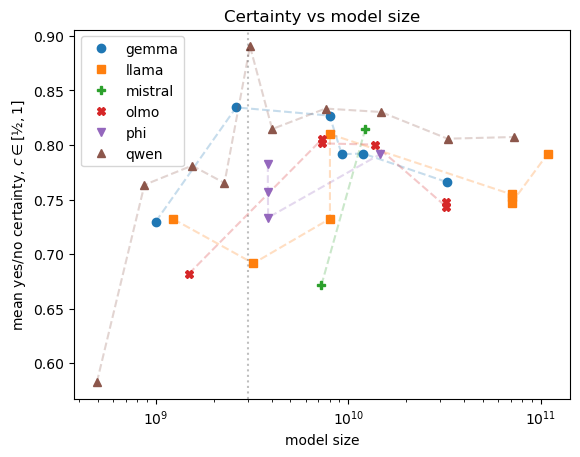

In [9]:
plt.figure()
plt.title('Certainty vs model size')
for label_index, label in enumerate(unique):
    x = np.array([plot_size[i] for i in range(len(plot_labels)) if plot_labels[i] == label])
    y = np.array([plot_certainty[i] for i in range(len(plot_labels)) if plot_labels[i] == label])
    i = np.argsort(x)
    marker = marker_map[label]
    plt.semilogx(x[i], y[i], marker=marker, label=label, linestyle='none', color=f'C{label_index}')
    plt.semilogx(x[i], y[i], marker='none', linestyle='--', alpha=0.25, color=f'C{label_index}')
plt.axvline(3e9, color='k', linestyle=':', alpha=0.25)
plt.legend()
plt.xlabel(r'model size')
plt.ylabel(r'mean yes/no certainty, $c \in [½,1]$')
plt.show()

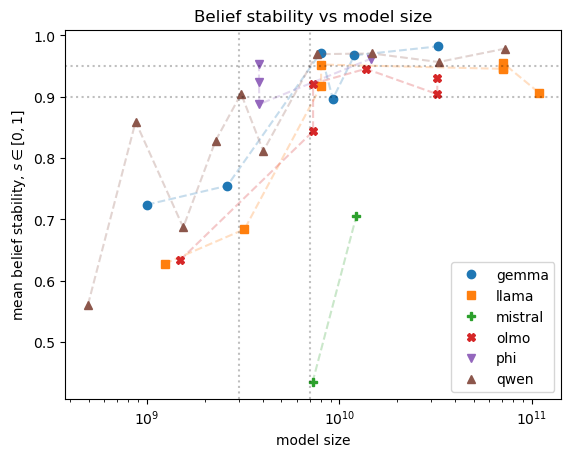

In [10]:
plt.figure()
plt.title('Belief stability vs model size')
for label_index, label in enumerate(unique):
    x = np.array([plot_size[i] for i in range(len(plot_labels)) if plot_labels[i] == label])
    y = np.array([plot_stability[i] for i in range(len(plot_labels)) if plot_labels[i] == label])
    i = np.argsort(x)
    marker = marker_map[label]
    plt.semilogx(x[i], y[i], marker=marker, label=label, linestyle='none', color=f'C{label_index}')
    plt.semilogx(x[i], y[i], marker='none', linestyle='--', alpha=0.25, color=f'C{label_index}')
plt.axvline(3e9, color='k', linestyle=':', alpha=0.25)
plt.axvline(7e9, color='k', linestyle=':', alpha=0.25)
plt.axhline(0.9, color='k', linestyle=':', alpha=0.25)
plt.axhline(0.95, color='k', linestyle=':', alpha=0.25)
plt.legend()
plt.xlabel(r'model size')
plt.ylabel(r'mean belief stability, $s \in [0,1]$')
plt.show()

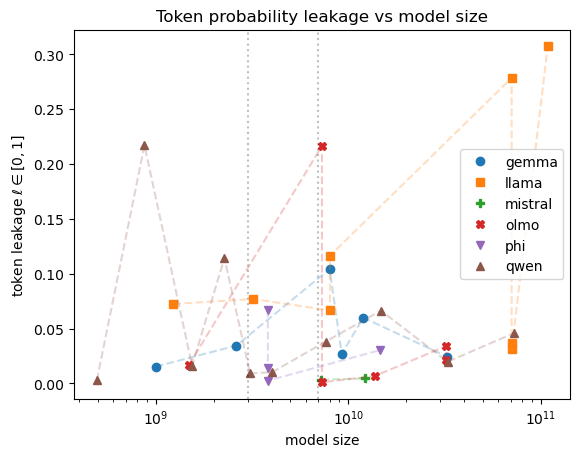

In [11]:
plt.figure()
plt.title('Token probability leakage vs model size')
for label_index, label in enumerate(unique):
    x = np.array([plot_size[i] for i in range(len(plot_labels)) if plot_labels[i] == label])
    y = np.array([plot_leakage[i] for i in range(len(plot_labels)) if plot_labels[i] == label])
    i = np.argsort(x)
    marker = marker_map[label]
    plt.semilogx(x[i], y[i], marker=marker, label=label, linestyle='none', color=f'C{label_index}')
    plt.semilogx(x[i], y[i], marker='none', linestyle='--', alpha=0.25, color=f'C{label_index}')
plt.axvline(3e9, color='k', linestyle=':', alpha=0.25)
plt.axvline(7e9, color='k', linestyle=':', alpha=0.25)
plt.legend()
plt.xlabel(r'model size')
plt.ylabel(r'token leakage $\ell \in [0,1]$')
plt.show()

In [12]:
max_leakage = 1
min_stability = 0.9
for i, _ in sorted(enumerate(plot_size), key=lambda item: item[1]):
    if plot_leakage[i] < max_leakage and plot_stability[i] > min_stability:
        print(plot_slug[i], plot_size[i], plot_stability[i], plot_leakage[i])

Qwen2.5-3B-Instruct 3085938688 0.9048908 0.009180676
Phi-3.5-mini-instruct 3821079552 0.95433617 0.06720309
Phi-3-mini-128k-instruct 3821079552 0.9236359 0.013742053
OLMo-2-1124-7B-Instruct 7298617344 0.9214966 0.0010150144
Qwen2.5-7B-Instruct 7615616512 0.9695288 0.03804328
gemma-4-E4B-it 7996156490 0.9721249 0.10421539
Llama-3.1-8B-Instruct 8030261248 0.91791904 0.06649584
Meta-Llama-3-8B-Instruct 8030261248 0.9526383 0.11639568
gemma-4-12B-it 11959730224 0.9676654 0.05989355
OLMo-2-1124-13B-Instruct 13716198400 0.94571847 0.006761202
phi-4 14659507200 0.9624871 0.030425474
Qwen2.5-14B-Instruct 14770033664 0.9706791 0.06637569
Olmo-3.1-32B-Instruct 32233522176 0.90434414 0.033992566
OLMo-2-0325-32B-Instruct 32234279936 0.9314825 0.020995883
gemma-4-31B-it 32682372656 0.9823523 0.024365555
Qwen2.5-32B-Instruct 32763876352 0.95675087 0.019779243
Meta-Llama-3-70B-Instruct 70553706496 0.94560224 0.27836674
Llama-3.1-70B-Instruct 70553706496 0.94694394 0.037282985
Llama-3.3-70B-Instruct 7